# CG Reconstruction Example

This notebook demonstrates compressed sensing reconstruction using the Conjugate Gradient (CG) method.

The CG reconstructor minimizes ChiSquared + regularization terms to recover sparse Faraday depth spectra.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from csromer.optimization.methods.cg import PolakRibiere
from csromer.pipelines.reconstruction import CSROMERReconstructorWrapper, make_cg_optimizer
from csromer.pipelines.simulation import ApplyNoiseStep, SimulateStep, run_simulation
from csromer.simulation import FaradayThinSource
from csromer.utils.array_utils import asnumpy

plt.rcParams['figure.figsize'] = (14, 8)
%matplotlib inline

## 1. Create Test Source with Noise

In [2]:
# Create source and run simulation pipeline (simulate + noise)
nu = np.linspace(1.0e9, 1.5e9, 128)
source = FaradayThinSource(
    nu=nu,
    s_nu=0.1,
    phi_gal=50.0,
    spectral_idx=-0.7,
)
run_simulation(
    source, [
        SimulateStep(),
        ApplyNoiseStep(0.01, random_state=np.random.RandomState(42)),
    ]
)

print(f"Source:")
print(f"  True RM: {source.phi_gal:.2f} rad/m²")
print(f"  Flux: {source.s_nu:.3f} Jy")
print(f"  Channels: {len(nu)}")

Source:
  True RM: 50.00 rad/m²
  Flux: 0.100 Jy
  Channels: 128


## 2. Run CG Reconstruction

In [3]:
# Create reconstructor (CG via optimizer_factory)
recon = CSROMERReconstructorWrapper(
    dataset=source,
    oversampling=7.0,
    optimizer_factory=make_cg_optimizer(maxiter=5000, tol=1e-12, verbose=True, method=PolakRibiere),
    lambda_l_norm=0.8,
    measurement_operator_kind="gridded"
)

# Run reconstruction
recon.reconstruct()

print(f"\nReconstruction Results:")
print(f"  Dirty RM: {recon.rm_dirty:.2f} rad/m²")
print(f"  Model RM: {recon.rm_model:.2f} rad/m²")
print(f"  Restored RM: {recon.rm_restored:.2f} rad/m²")
print(f"  True RM: {source.phi_gal:.2f} rad/m²")

FWHM of the main peak of the RMTF: 15.406 rad/m^2
Maximum recovered width structure: 78.649 rad/m^2
Maximum Faraday Depth to which one has more than 50% sensitivity: 4405.503
Starting Polak-Ribiere-Polyak (Conjugate Gradient)
Initial function value = 299.004516
Iteration 1  objective = 299.0045161585888
Polak-Ribiere-Polyak converged after 10 iterations
Convolving with Gaussian kernel where FWHM 15.240 rad/m^2 - sigma 6.472 rad/m^2 - sigma_pixels 2.9381
  [convolve_fd] kernel len=25 sum=7.364534 max=1.000000
Convolving with Gaussian kernel where FWHM 15.240 rad/m^2 - sigma 6.472 rad/m^2 - sigma_pixels 2.9381
  [convolve_fd] kernel len=25 sum=7.364534 max=1.000000
Convolving with Gaussian kernel where FWHM 15.240 rad/m^2 - sigma 6.472 rad/m^2 - sigma_pixels 2.9381
  [convolve_fd] kernel len=25 sum=7.364534 max=1.000000
[restore DEBUG]
  cellsize=2.202752  rmtf_fwhm=15.240069  pixels_per_rmtf=6.9187
  peak:  dirty=9.962260e-02  model=4.059083e-03  residual=9.384819e-03
  peak:  conv_mode

/home/miguel/Documents/repositories/csromer/src/csromer/optimization/methods/cg.py:64: RuntimeWarning: Polak-Ribiere-Polyak: F_obj contains a non-differentiable term (e.g. L1 regularization). This CG implementation's line search will not take a step that increases the objective, but its smoothed-gradient handling of non-differentiable terms is weaker at inducing sparsity/flux concentration than a proximal method's exact prox step -- consider FISTA if that term needs to meaningfully shape the solution.
  self._warn_if_nonsmooth_objective()


In [4]:
n_channels = recon.dataset.m
sum_weights = np.sum(recon.dataset.w)
print(f"n_channels: {n_channels}, sum_weights: {sum_weights}, ratio: {n_channels / sum_weights}")

n_channels: 4000, sum_weights: 7458505.5, ratio: 0.000536300469309837


## 3. Visualize Results

**Units (CLEAN/RML convention):**
- **Dirty** and **restored** are in **Jy/rmtf** (flux per unit RMTF).
- **Model** is in **Jy/phi_pixel** (flux per phi pixel). The optimizer works in Jy/phi_pixel and **starts from complex zeros** (not from the dirty map). Restored = convolved model (scaled to Jy/rmtf) + residual.
- So model amplitude is not directly comparable to dirty/restored on the same y-axis.

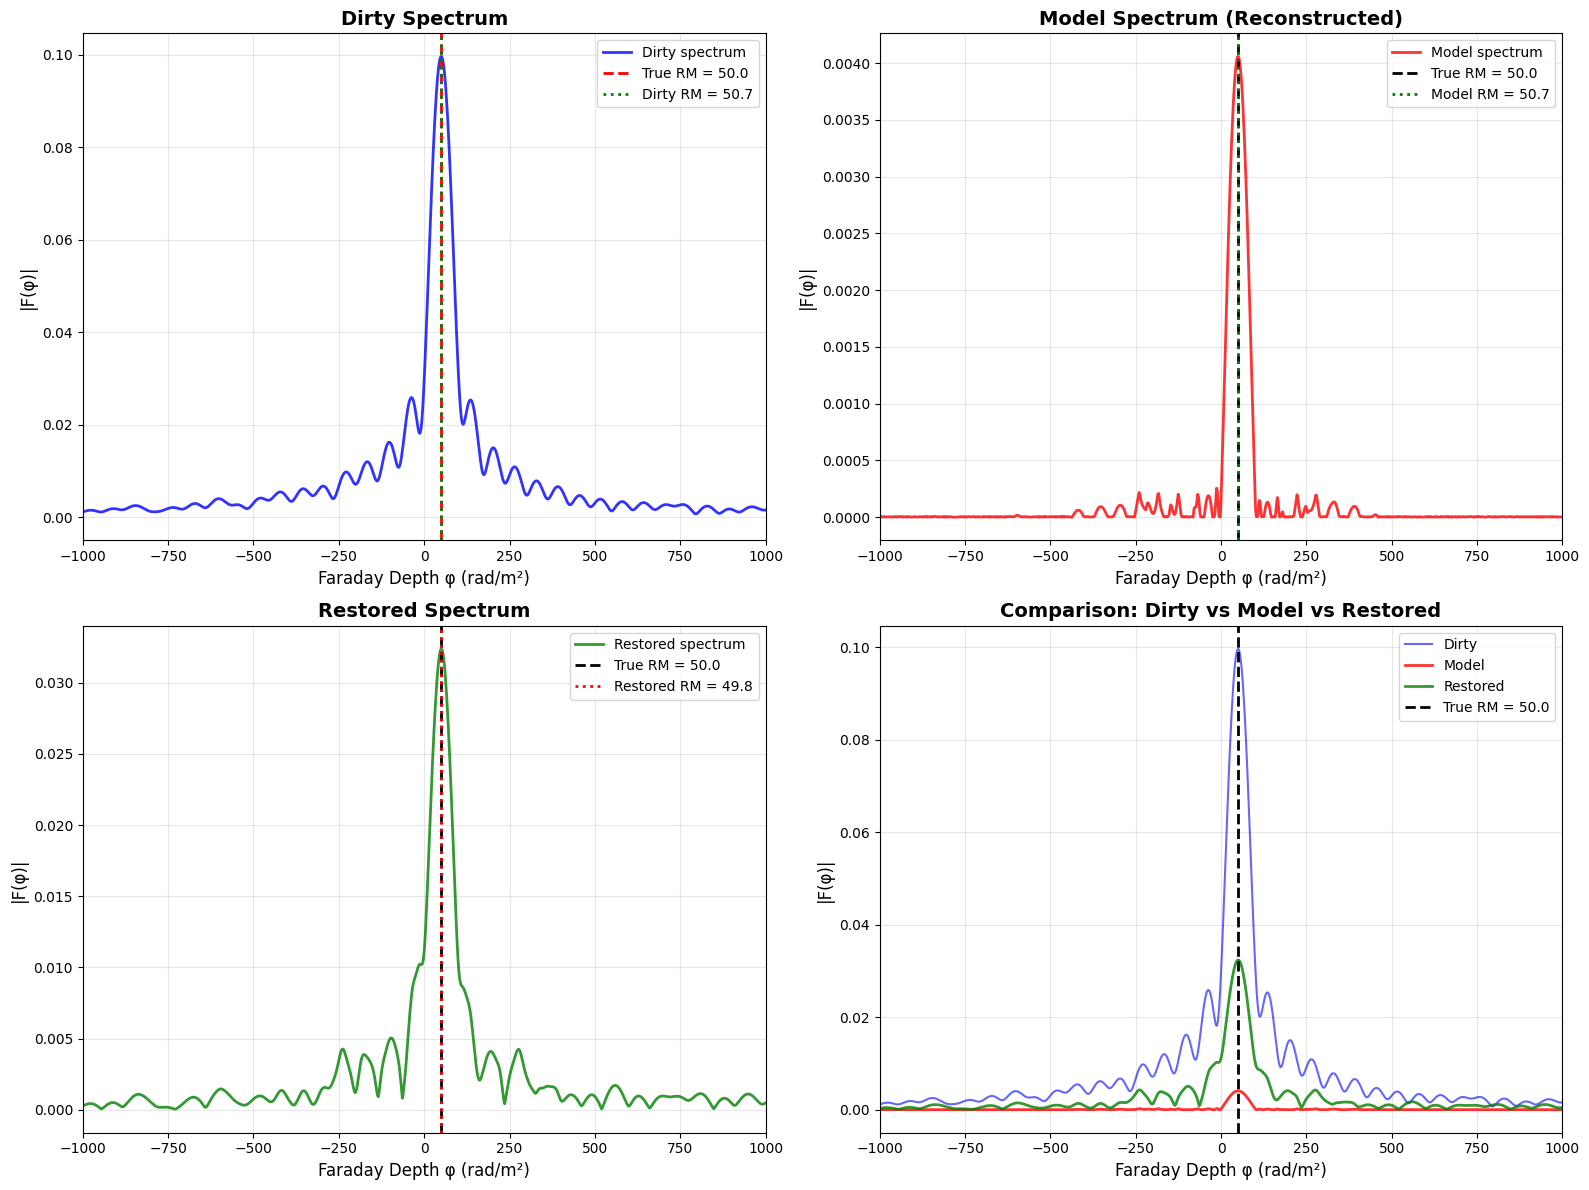

In [5]:
phi = np.asarray(asnumpy(recon.parameter.phi))
fd_dirty = np.asarray(asnumpy(recon.fd_dirty))
fd_model = np.asarray(asnumpy(recon.fd_model))
fd_restored = np.asarray(asnumpy(recon.fd_restored_abs))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Dirty spectrum
ax = axes[0, 0]
ax.plot(phi, np.abs(fd_dirty), 'b-', linewidth=2, label='Dirty spectrum', alpha=0.8)
ax.axvline(
    source.phi_gal, color='r', linestyle='--', linewidth=2, label=f'True RM = {source.phi_gal:.1f}'
)
ax.axvline(
    recon.rm_dirty, color='g', linestyle=':', linewidth=2, label=f'Dirty RM = {recon.rm_dirty:.1f}'
)
ax.set_xlabel('Faraday Depth φ (rad/m²)', fontsize=12)
ax.set_ylabel('|F(φ)|', fontsize=12)
ax.set_title('Dirty Spectrum', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(-1000, 1000)

# Plot 2: Model spectrum
ax = axes[0, 1]
ax.plot(phi, np.abs(fd_model), 'r-', linewidth=2, label='Model spectrum', alpha=0.8)
ax.axvline(
    source.phi_gal, color='k', linestyle='--', linewidth=2, label=f'True RM = {source.phi_gal:.1f}'
)
ax.axvline(
    recon.rm_model, color='g', linestyle=':', linewidth=2, label=f'Model RM = {recon.rm_model:.1f}'
)
ax.set_xlabel('Faraday Depth φ (rad/m²)', fontsize=12)
ax.set_ylabel('|F(φ)|', fontsize=12)
ax.set_title('Model Spectrum (Reconstructed)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(-1000, 1000)

# Plot 3: Restored spectrum
ax = axes[1, 0]
ax.plot(phi, fd_restored, 'g-', linewidth=2, label='Restored spectrum', alpha=0.8)
ax.axvline(
    source.phi_gal, color='k', linestyle='--', linewidth=2, label=f'True RM = {source.phi_gal:.1f}'
)
ax.axvline(
    recon.rm_restored,
    color='r',
    linestyle=':',
    linewidth=2,
    label=f'Restored RM = {recon.rm_restored:.1f}'
)
ax.set_xlabel('Faraday Depth φ (rad/m²)', fontsize=12)
ax.set_ylabel('|F(φ)|', fontsize=12)
ax.set_title('Restored Spectrum', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(-1000, 1000)

# Plot 4: Comparison
ax = axes[1, 1]
ax.plot(phi, np.abs(fd_dirty), 'b-', linewidth=1.5, label='Dirty', alpha=0.6)
ax.plot(phi, np.abs(fd_model), 'r-', linewidth=2, label='Model', alpha=0.8)
ax.plot(phi, fd_restored, 'g-', linewidth=2, label='Restored', alpha=0.8)
ax.axvline(
    source.phi_gal, color='k', linestyle='--', linewidth=2, label=f'True RM = {source.phi_gal:.1f}'
)
ax.set_xlabel('Faraday Depth φ (rad/m²)', fontsize=12)
ax.set_ylabel('|F(φ)|', fontsize=12)
ax.set_title('Comparison: Dirty vs Model vs Restored', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(-1000, 1000)

plt.tight_layout()
plt.show()

(-1000.0, 1000.0)

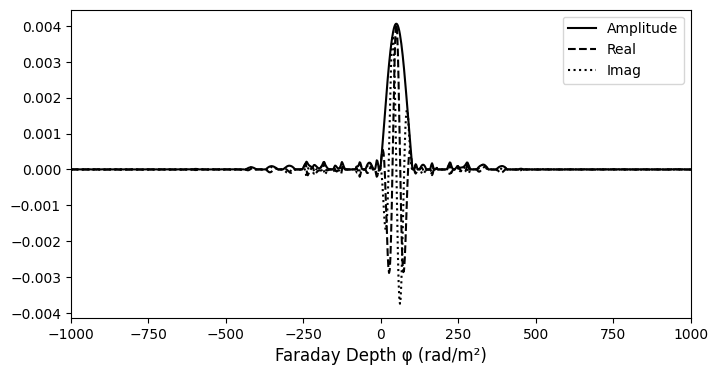

In [6]:
model = recon.fd_model

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(phi, np.abs(model), color='black', linestyle='-', label='Amplitude')
ax.plot(phi, model.real, color='black', linestyle='--', label='Real')
ax.plot(phi, model.imag, color='black', linestyle=':', label='Imag')
ax.legend()
ax.set_xlabel('Faraday Depth φ (rad/m²)', fontsize=12)
ax.set_xlim(-1000, 1000)

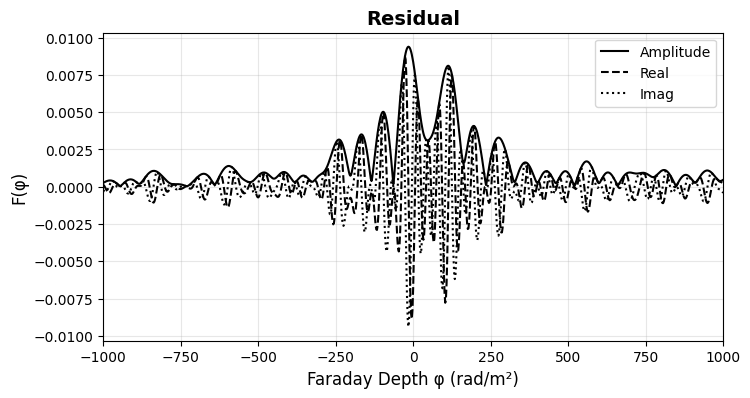

In [7]:
residual = recon.fd_residual

fig, ax = plt.subplots(1, 1, figsize=(8, 4))

ax.plot(phi, np.abs(residual), color='black', linestyle='-', label='Amplitude')
ax.plot(phi, residual.real, color='black', linestyle='--', label='Real')
ax.plot(phi, residual.imag, color='black', linestyle=':', label='Imag')
ax.legend()
ax.set_xlabel('Faraday Depth φ (rad/m²)', fontsize=12)
ax.set_ylabel('F(φ)', fontsize=12)
ax.set_title('Residual', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim(-1000, 1000)
plt.show()

Text(0.5, 0, 'Faraday Depth φ (rad/m²)')

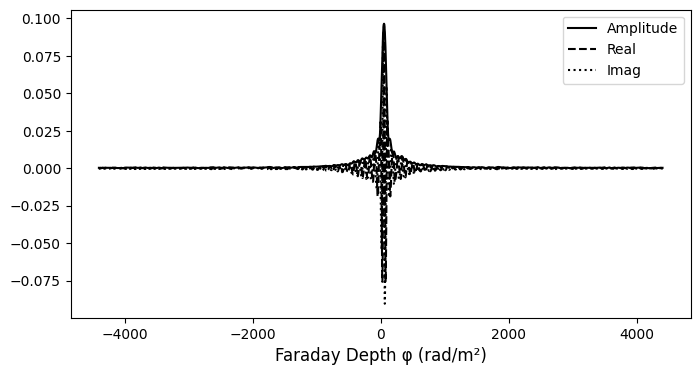

In [8]:
# Dirty of the model
dirty_model = recon.measurement_operator.dirty_spectrum(recon.dataset.model_data)
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(phi, np.abs(dirty_model), color='black', linestyle='-', label='Amplitude')
ax.plot(phi, dirty_model.real, color='black', linestyle='--', label='Real')
ax.plot(phi, dirty_model.imag, color='black', linestyle=':', label='Imag')
ax.legend()
ax.set_xlabel('Faraday Depth φ (rad/m²)', fontsize=12)

## 4. Quality Metrics

In [9]:
print("Quality Metrics:")
print(f"  Dirty RM: {recon.rm_dirty:.3f} ± {recon.rm_dirty_error:.3f} rad/m²")
print(f"  Model RM: {recon.rm_model:.3f} rad/m²")
print(f"  Restored RM: {recon.rm_restored:.3f} ± {recon.rm_restored_error:.3f} rad/m²")
print(f"\n  Second moment: {recon.second_moment:.3f} rad²/m⁴")
print(f"  RMTF FWHM: {recon.parameter.rmtf_fwhm:.3f} rad/m²")

# Check if RM recovery is within tolerance
tolerance = recon.parameter.rmtf_fwhm * 2.0
rm_error_model = abs(recon.rm_model - source.phi_gal)
rm_error_dirty = abs(recon.rm_dirty - source.phi_gal)

print(f"\nRM Recovery:")
print(f"  Model error: {rm_error_model:.3f} rad/m² (tolerance: {tolerance:.3f})")
print(f"  Dirty error: {rm_error_dirty:.3f} rad/m² (tolerance: {tolerance:.3f})")

if rm_error_model < tolerance:
    print(f"  ✓ Model RM recovery successful!")
else:
    print(f"  ⚠ Model RM error exceeds tolerance")

if rm_error_dirty < tolerance:
    print(f"  ✓ Dirty RM recovery successful!")
else:
    print(f"  ⚠ Dirty RM error exceeds tolerance")

Quality Metrics:
  Dirty RM: 50.663 ± 0.007 rad/m²
  Model RM: 50.663 rad/m²
  Restored RM: 49.808 ± 0.105 rad/m²

  Second moment: 542469.573 rad²/m⁴
  RMTF FWHM: 15.240 rad/m²

RM Recovery:
  Model error: 0.663 rad/m² (tolerance: 30.480)
  Dirty error: 0.663 rad/m² (tolerance: 30.480)
  ✓ Model RM recovery successful!
  ✓ Dirty RM recovery successful!
